# Simulating a Basket of Stocks


## Introduction

Consider a stock with $S_0$ as its current price. Using the geometric Brownian motion to model stock prices, the stock price $S_{T}$ after $T$ years is given by:

$$ S_T = S_0 \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}z\right) $$

where $\mu$ is the expected return of the stock, $\sigma$ is the historical volatility of the stock, and $z$ denotes the standard normal variable.

Now, consider a basket of $n$ stocks, $S_1, S_2, ..., S_n$, with weights $w_1, w_2, ..., w_n$, $\sum_{i=1}^n w_i = 1$. Let $S_{i, 0}$ denote the current price of stock $S_i$. 

We inquire now as to the value of the basket after $T$ years, $B_T$. Let $S_{i, T}$ denote the price of stock $S_i$ after $T$ years. Then, 

$$ B_T = \sum_{i = 1}^{n} w_i S_{i, T}. $$

Here,

$$ S_{i, T} = S_{i, 0} \exp \left( \left( \mu_{i} - \frac{1}{2} \sigma_{i}^{2} \right) T + \sqrt{T} X_{i} \right) $$

where $\mu_{i}$ is the expected return of stock $S_i$ and $\sigma_{i}$ volatility of stock $S_i$. Note that we cannot simply take $z$ here from the standard normal distribution, for the correlation between the various stocks affects $S_{i, T}$. Instead, we use $ X = (X_1, X_2, ..., X_n) \sim \mathcal{N}(0, \Sigma)$, where $\Sigma$ is the covariance matrix, defined as follows:

Let $R$ be a $n \times d$ matrix such that the $i$-th row of $R$ contains the daily log returns of the stock $S_i$ and let $\Sigma$ be the covariance matrix due to $R$. Then, we require that $X \sim \mathcal{N}(0, \Sigma)$, that is, $\text{Cov}(X) = \Sigma$. 

In order to obtain $X$, we start with $Z \sim \mathcal{N}(0, I)$. Then, $\text{Cov}(Z) = I$. 

Since $\Sigma$ is symmetric and positive definite, there exists a lower triangular matrix $L$ such that

$$ \Sigma = L L ^ \top .$$

Define $X = LZ$. Then, $\text{Cov}(X) = \text{Cov}(LZ) = L \, \text{Cov}(Z) \, L ^ \top = LIL^\top = LL ^ \top = \Sigma$, and thus we see that $X = LZ$ is our desired vector. 

## Implementation

The following function can be used to simulate the terminal prices of a basket of stocks:

In [1]:
import yfinance as yf
import numpy as np

In [2]:
'''
Simulating the terminal prices of a basket of stocks.

tickers: a list of strings like ["AAPL", "MSFT"]
T: time in years
weights: weights[i] denotes what fraction of the basket is the i-th stock; value between 0 and 1, sum(weights) = 1
num_sim: number of simulations

'''

def sim_stock_basket(tickers, T, weights, num_sim):
    num_stocks = len(tickers)
    
    # 2 year history of all stocks in "tickers". We take transpose so that each row represents history of a stock.
    hist = yf.Tickers(tickers).history(period="2y")["Close"].to_numpy().T

    # last available prices
    S_0 = hist[:, -1].reshape(-1, 1)
    
    # daily log returns
    R = np.log(hist[:, 1:] / hist[:, :-1])
    
    # mean and volatility of all stocks
    means = np.mean(R, axis=1).reshape(-1, 1) * 252  # multiply by 252 to annualize
    sigma = np.std(R, axis=1).reshape(-1, 1) * np.sqrt(252)  # multiply by sqrt(252) to annualize 
    
    cov_mat = np.cov(R) * 252  # covariance matrix, annualized
    
    L = np.linalg.cholesky(cov_mat)  # lower triangular matrix obtained from Cholesky decomposition
    Z = np.random.randn(num_stocks, num_sim)  # forms a num_stocks x num_sim matrix of values taken from the standard normal distribution

    X = L @ Z  # correlated shocks
    
    S_T = S_0 * np.exp((means - 0.5 * sigma ** 2) * T + np.sqrt(T) * X)  # terminal stock prices
    
    w = np.array(weights).reshape(1, -1)
    
    return w @ S_T  # simulated values of the basket of stocks

For example, we consider the following basket of stocks:

In [3]:
tickers = ["AAPL", "MSFT", "NVDA"]
weights = [0.5, 0.1, 0.4]
T = 1
num_sim = 50000

A = sim_stock_basket(tickers, T, weights, num_sim)

[*********************100%***********************]  3 of 3 completed


In [4]:
from pylab import plt

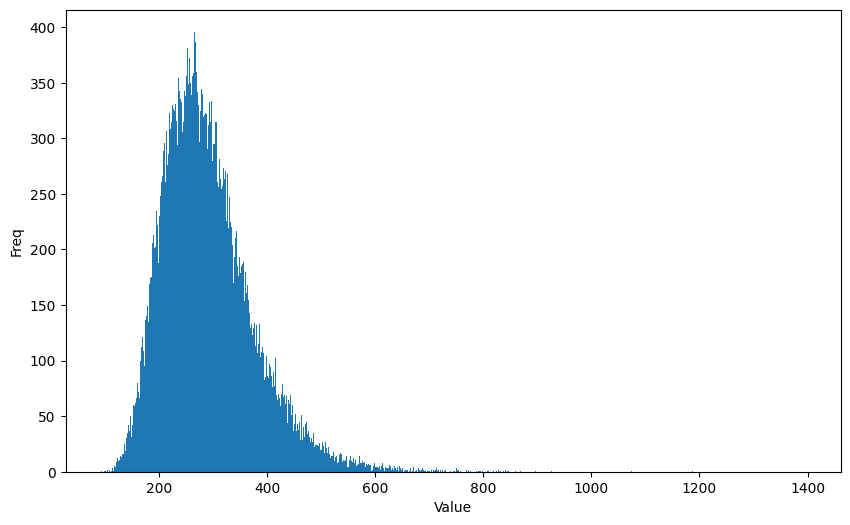

In [5]:
data = A.ravel()

plt.figure(figsize=(10, 6))
plt.hist(data, bins = 1000)
plt.xlabel('Value')
plt.ylabel('Freq')
plt.show()

We may wish to simulate the entire path followed by the price of the basket of stocks. This can be done by discretization: we can divide the total time period $T$ into a certain number of intervals, $n$. Each interval is of duration $\Delta t = T / n$. Then, for a single stock, 

$$ S_{t} = S_{t - \Delta t} \exp \left( \left( \mu - \frac{1}{2} \sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} \, z\right). $$

That is, at the end of each interval, we calculate the possible stock price $S_t$ by considering the initial stock price as the price before that interval, $S_{t - \Delta t}$, and the duration is set to $\Delta t$. This can be extended to multiple stocks as before. In the implementation that follows, a three-dimensional `ndarray` called `price_data` is used: `price_data[i]` denotes the simulated paths for the $i$-th stock and is a two-dimensional matrix in which the rows represent the intervals and each column represents one simulated path. For each interval, the correlated shocks are recalculated. 

In [6]:
'''
Simulating paths followed by the price of the basket of stocks.

tickers: a list of strings like ["AAPL", "MSFT"]
T: time in years
weights: weights[i] denotes what fraction of the basket is the i-th stock; value between 0 and 1, sum(weights) = 1
num_sim: number of simulations 
num_int: number of intervals

'''

def stock_basket_path(tickers, T, weights, num_sim, num_int):
    dt = T / num_int   # length of each interval
    num_stocks = len(tickers)
                    
    hist = yf.Tickers(tickers).history(period="2y")["Close"].to_numpy().T
    price_data = np.zeros((num_stocks, num_int + 1, num_sim))
    curr_stock_prices = hist[:, -1].reshape(-1, 1)

    for i in range(0, num_stocks):
        price_data[i, 0, :] = curr_stock_prices[i]

    R = np.log(hist[:, 1:] / hist[:, :-1])

    means = np.mean(R, axis=1).reshape(-1, 1) * 252
    sigma = np.std(R, axis=1).reshape(-1, 1) * np.sqrt(252)
    cov_mat = np.cov(R) * 252

    L = np.linalg.cholesky(cov_mat)

    for t in range(1, num_int + 1):
        Z = np.random.randn(num_stocks, num_sim)
        X = L @ Z

        price_data[:, t, :] = price_data[:, t - 1, :] * np.exp((means - 0.5 * sigma ** 2) * dt + np.sqrt(dt) * X)

    weights = np.array(weights).reshape(-1, 1, 1)
    basket_paths = np.sum(weights * price_data, axis = 0)
    
    return basket_paths

Consider the following example with 50 intervals:

In [7]:
tickers = ["AAPL", "MSFT", "NVDA"]
weights = [0.5, 0.1, 0.4]

num_int = 50
num_sim = 50000
T = 1
dt = T / num_int

[*********************100%***********************]  3 of 3 completed


Text(0, 0.5, 'Price of the Basket of Stocks (in dollars)')

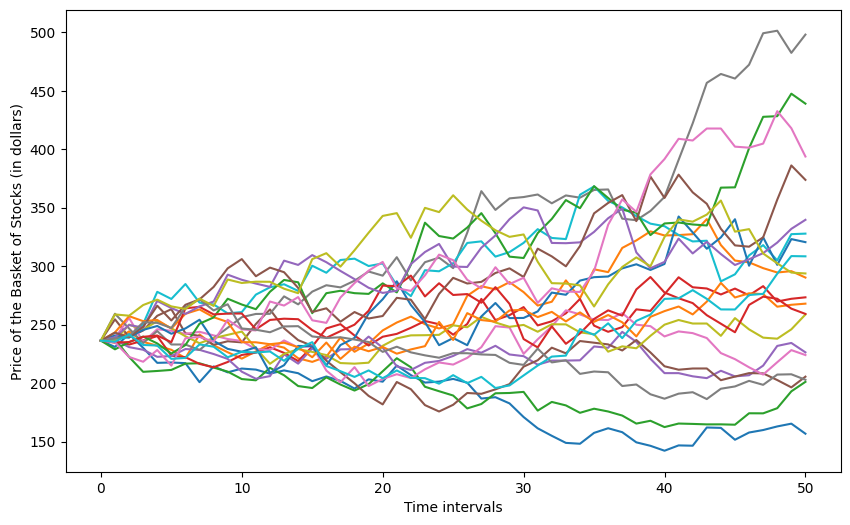

In [8]:
basket_paths = stock_basket_path(tickers, T, weights, num_sim, num_int)

plt.figure(figsize=(10, 6))
plt.plot(basket_paths[:, :20])
plt.xlabel("Time intervals")
plt.ylabel("Price of the Basket of Stocks (in dollars)")

In [9]:
np.set_printoptions(precision=4, suppress=True)
basket_paths

array([[236.309 , 236.309 , 236.309 , ..., 236.309 , 236.309 , 236.309 ],
       [230.9076, 236.6146, 237.6334, ..., 245.8477, 232.2085, 248.8867],
       [241.9172, 244.1994, 222.3725, ..., 244.7091, 229.5647, 249.113 ],
       ...,
       [162.9123, 294.5967, 178.5134, ..., 256.9882, 393.5842, 204.1232],
       [165.2911, 295.7371, 192.9324, ..., 271.4238, 397.6179, 194.4745],
       [156.6994, 290.2658, 201.0614, ..., 279.4185, 380.7721, 194.2241]],
      shape=(51, 50000))

The simulated terminal prices of the basket are stored in the last row of `basket_paths`:

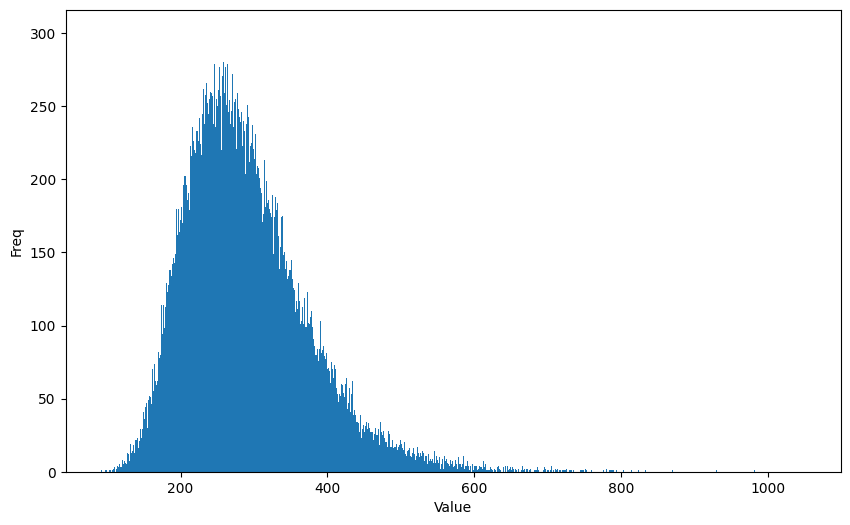

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(basket_paths[-1, :], bins = 1000)
plt.xlabel('Value')
plt.ylabel('Freq')
plt.show()